# import library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile

from collections import Counter
from itertools import combinations

* pandas dipakai untuk memanipulasi dan analisis data
* numpy digunakan untuk membantu operasi numerik
* matplotlib dan seaborn digunakan untuk visualisasi data
* zipfile digunakan untuk membuka dataset berbentuk zip
* Counter  digunakan untuk menghitung frekuinsi kata atau pasangan skill

# import dataset

In [2]:
# !pip install -q gdown

# !gdown --fuzzy "https://drive.google.com/file/d/1sO_Q-tYvQGBrwkYkBvkonm_4XJaimh6u/view?usp=drive_link"

In [3]:
# import os
# os.listdir()

In [4]:
# import zipfile

# with zipfile.ZipFile('cleaned_data.zip', 'r') as zip_ref:
#     zip_ref.extractall('extracted_data')

# print("Dataset berhasil diextract")

In [5]:
# os.listdir('extracted_data/cleaned_data')

# load dataset

In [6]:
df = pd.read_csv('../dataset/cleaned_data/cleaned_data.csv')

In [7]:
df.head()

,title,description,char_count,text,word_count,cleaned_text
0,10 + Blockchain Nodes / Masternodes to set up,*Requirements*\r\n\r\nWe're looking for a long...,388,10 + Blockchain Nodes / Masternodes to set up ...,63,blockchain nodes masternodes set requirements ...
1,10 .NET Developers (Middle and Senior level),"Greetings! My name is Maria, I am in urgent ne...",1380,10 .NET Developers (Middle and Senior level) G...,207,net developers middle senior level greetings n...
2,"10X Engineer (co-founder, #4 employee, USD 11-...",**Product**\r\nThe product is a live video cha...,2649,"10X Engineer (co-founder, #4 employee, USD 11-...",420,x engineer co founder employee usd k equity pr...
3,16 - Amazon Brand Manager,"Currently, TCM expanding its activities to Ukr...",4088,"16 - Amazon Brand Manager Currently, TCM expan...",587,amazon brand manager currently tcm expanding a...
4,16 - Amazon Brand Manager,"Hello,\r\nWe, MIMIRB2B, are an outstaff compan...",3705,"16 - Amazon Brand Manager Hello,\r\nWe, MIMIRB...",531,amazon brand manager hello mimirbb outstaff co...


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 151816 entries, 0 to 151815
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   title         151816 non-null  str  
 1   description   151704 non-null  str  
 2   char_count    151816 non-null  int64
 3   text          151816 non-null  str  
 4   word_count    151816 non-null  int64
 5   cleaned_text  151816 non-null  str  
dtypes: int64(2), str(4)
memory usage: 787.1 MB


# Checking Missing Value

In [9]:
df.isnull().sum()

title             0
description     112
char_count        0
text              0
word_count        0
cleaned_text      0
dtype: int64

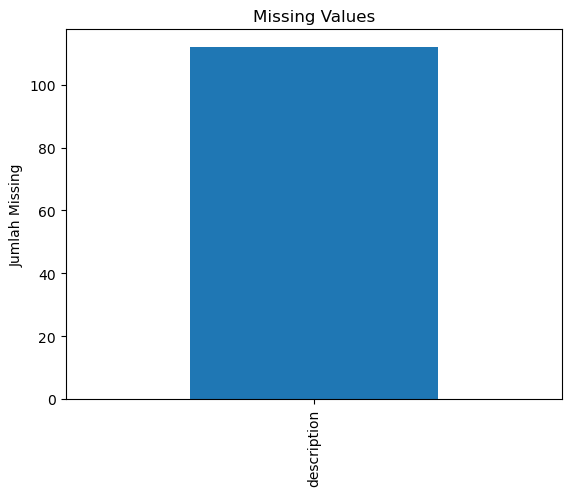

In [10]:
missing = df.isnull().sum()

missing[missing > 0].plot(kind='bar')

plt.title("Missing Values")
plt.ylabel("Jumlah Missing")
plt.show()

Theres a bit of missing data in `description` but since the column we will use is `cleaned_text`, we will ignore the missing data

# duplicate check

In [11]:
print("Jumlah duplicate:", df.duplicated().sum())

Jumlah duplicate: 1267


In [12]:
for col in df.columns:
    dup_count = df[col].duplicated().sum()
    print(f"{col}: {dup_count}")

title: 75444
description: 1567
char_count: 145650
text: 1267
word_count: 150592
cleaned_text: 1397


In [13]:
dups = df[df.duplicated('cleaned_text', keep=False)]

dups[['cleaned_text']].sort_values('cleaned_text')

,cleaned_text
143057,__ __ __ area sales representative_pt
146976,__ __ __ area sales representative_pt
151770,__ __ __ area sales representative_pt
143062,__ jmp __ __ __ jmp __ __ __ legal entity : bo...
145173,__ jmp __ __ __ jmp __ __ __ legal entity : bo...
...,...
147294,workshop receptionist workshop receptionist fu...
142893,wp __ __ __ project manager electrification tw...
146237,wp __ __ __ project manager electrification tw...
142358,zf ai internship program zf global technology ...


In [14]:
# Drop duplicate rows based on cleaned_text 
df = df.drop_duplicates(subset='cleaned_text')

In [15]:
df.loc[df.duplicated('cleaned_text'), 'cleaned_text']

Series([], Name: cleaned_text, dtype: str)

# statistik dasar

In [16]:
df.describe(include='all')

,title,description,char_count,text,word_count,cleaned_text
count,150419,150316,150419.000000,150419,150419.000000,150419
unique,76338,150141,NaN,150419,NaN,150419
top,DevOps Engineer,**Praktikum Logistik w/m/div. (ab Jnner 2025)...,NaN,10 + Blockchain Nodes / Masternodes to set up ...,NaN,blockchain nodes masternodes set requirements ...
freq,1592,8,NaN,1,NaN,1
mean,NaN,NaN,1884.858322,NaN,275.356498,NaN
std,NaN,NaN,1065.272664,NaN,155.571797,NaN
min,NaN,NaN,0.000000,NaN,1.000000,NaN
25%,NaN,NaN,1135.000000,NaN,166.000000,NaN
50%,NaN,NaN,1682.000000,NaN,245.000000,NaN
75%,NaN,NaN,2393.000000,NaN,349.000000,NaN


# analisis panjang teks

distribusi word count

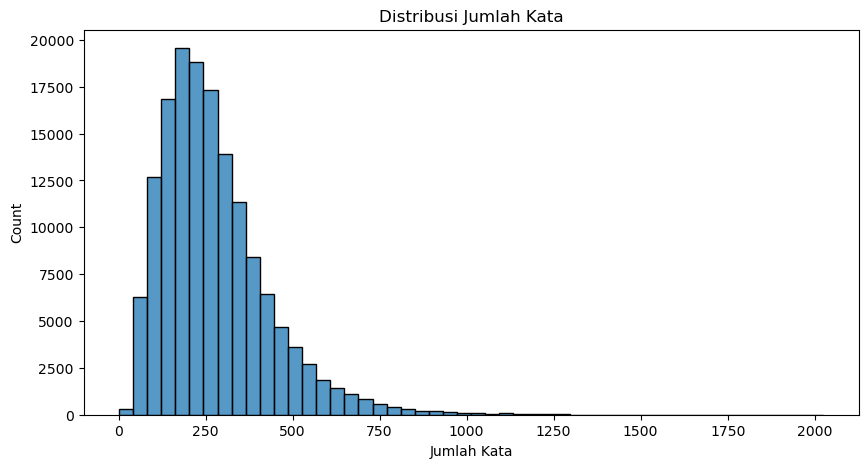

In [17]:
plt.figure(figsize=(10,5))

sns.histplot(df['word_count'], bins=50)

plt.title("Distribusi Jumlah Kata")
plt.xlabel("Jumlah Kata")

plt.show()

Insight:

* Puncak distribusi ada di kisaran < 1.000 kata
* Ini adalah pola umum pada data teks dunia nyata (hukum Zipf)

distribusi character count

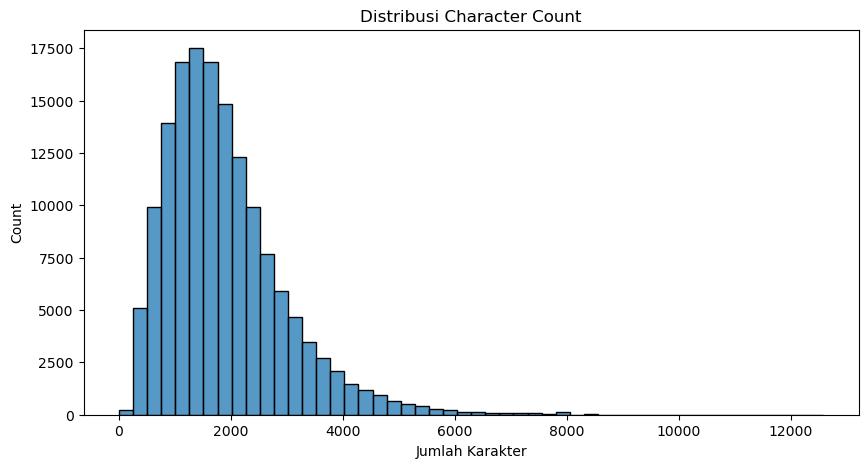

In [18]:
plt.figure(figsize=(10,5))

sns.histplot(df['char_count'], bins=50)

plt.title("Distribusi Character Count")
plt.xlabel("Jumlah Karakter")
plt.show()

Insight: Pola serupa dengan word count — right-skewed. Ini mengonfirmasi bahwa outlier bukan noise, melainkan dokumen nyata yang sangat panjang.

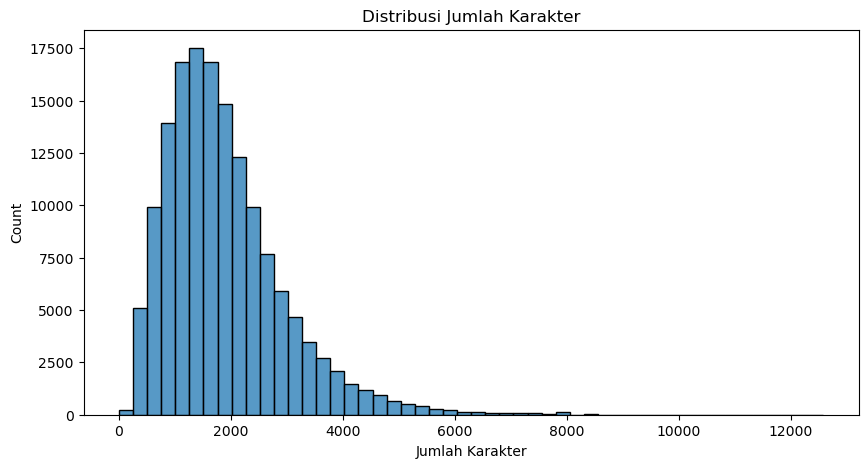

In [19]:
plt.figure(figsize=(10,5))

sns.histplot(df['char_count'], bins=50)

plt.title("Distribusi Jumlah Karakter")
plt.xlabel("Jumlah Karakter")

plt.show()

# Analisis Frequent Words

ambil semua kata

In [20]:
# Gabungkan semua kata dari kolom cleaned_text

all_words = ' '.join(df['cleaned_text'].astype(str)).split()

hitung frekuensi data

In [21]:
word_freq = Counter(all_words)

common_words = word_freq.most_common(25)

common_df = pd.DataFrame(common_words, columns=['word', 'count'])

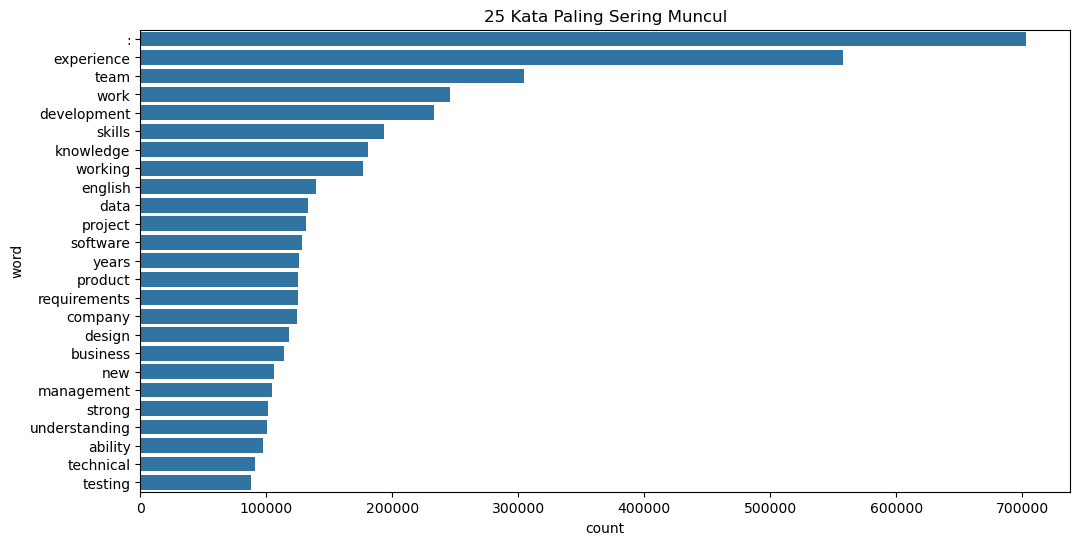

In [22]:
# Visualisasi

plt.figure(figsize=(12,6))

sns.barplot(
    x='count',
    y='word',
    data=common_df
)

plt.title("25 Kata Paling Sering Muncul")

plt.show()

Output: Bar chart horizontal 25 kata paling sering muncul.

Insight:

* Kata-kata paling sering muncul kemungkinan adalah kata umum (common terms) dalam konteks lowongan kerja seperti "experience", "work", "skills", dll.
* Ini berguna untuk memahami topik dominan dalam dataset
* Jika ada stop words yang masih muncul, perlu dilakukan pembersihan lebih lanjut

# Export dataset


In [66]:
df = (
    df
    .drop_duplicates(subset=['cleaned_text', 'text'])
    .drop(columns=['description', 'char_count', 'text', 'word_count'])
)

In [67]:
df

,title,cleaned_text
0,10 + Blockchain Nodes / Masternodes to set up,blockchain nodes masternodes set requirements ...
1,10 .NET Developers (Middle and Senior level),net developers middle senior level greetings n...
2,"10X Engineer (co-founder, #4 employee, USD 11-...",x engineer co founder employee usd k equity pr...
3,16 - Amazon Brand Manager,amazon brand manager currently tcm expanding a...
4,16 - Amazon Brand Manager,amazon brand manager hello mimirbb outstaff co...
...,...,...
151808,Lead IT Analyst,lead analyst become next futurestarter lead an...
151809,Senior Powertrain Sales Manager,senior powertrain sales manager become next fu...
151810,Retail Manager Trainee - Auchan Setbal,retail manager trainee auchan set bal retail m...
151814,Extracurricular Internship: Test Management (f...,extracurricular internship : test management f...


In [68]:
df.to_csv('../dataset/cleaned_data/dataset.csv', index=False)

We drop the secondary column and then clean the `cleaned_text`. After that Export it for the AI Engineer